# 🚗 CarCare AI — Data Inspection

## Project Overview

CarCare AI is an intelligent vehicle maintenance assistant that combines
Retrieval-Augmented Generation (RAG), a local Large Language Model (LLM),
and Computer Vision.

The system will use an automotive maintenance document as the main
knowledge source for RAG and the CarParts-Seg dataset for vehicle-part
detection.

### Main Goals

- Inspect and understand the automotive maintenance PDF.
- Extract and clean the document text for RAG.
- Inspect the CarParts-Seg computer vision dataset.
- Prepare the data for the next stages of the project.

### Project Components

- **RAG:** Automotive maintenance knowledge retrieval.
- **Vector Database:** ChromaDB.
- **Embeddings:** Sentence Transformers.
- **LLM:** Ollama local model.
- **Computer Vision:** YOLO / CarParts-Seg.
- **Backend:** FastAPI.
- **Frontend:** Streamlit.

## 1. Automotive Maintenance PDF Inspection

This section loads and inspects the automotive maintenance PDF used as the
knowledge source for the CarCare AI RAG pipeline.

We will verify:

* PDF file availability.
* Number of pages.
* Text extraction quality.
* Total extracted characters and words.
* Empty or suspicious pages.
* Sample pages from different sections.

The original page numbers are preserved because they will later be used
as source references in the RAG pipeline.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data"

print(f"Data folder: {DATA_DIR}")
print(f"Data folder exists: {DATA_DIR.exists()}")

pdf_files = list(DATA_DIR.glob("*.pdf"))

print(f"\nPDF files found: {len(pdf_files)}")

for pdf_file in pdf_files:
    print(f"- {pdf_file.name}")

Data folder: c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data
Data folder exists: True

PDF files found: 2
- automotivemainte00miln_0.pdf
- Vehicle Maintenance Vehicle Fitting Units Level 1 and 2 by Roy Brooks, Jack Hirst and John Whipp.pdf


In [3]:
from pypdf import PdfReader

# Select the new automotive maintenance PDF
PDF_PATH = DATA_DIR / "Vehicle Maintenance Vehicle Fitting Units Level 1 and 2 by Roy Brooks, Jack Hirst and John Whipp.pdf"

print(f"Selected PDF:")
print(PDF_PATH.name)
print(f"\nFile exists: {PDF_PATH.exists()}")

# Read PDF
pdf_reader = PdfReader(str(PDF_PATH))
num_pages = len(pdf_reader.pages)

print(f"Number of pages: {num_pages}")

Selected PDF:
Vehicle Maintenance Vehicle Fitting Units Level 1 and 2 by Roy Brooks, Jack Hirst and John Whipp.pdf

File exists: True
Number of pages: 145


In [4]:
# Extract text from all PDF pages

page_texts = []

for page_number, page in enumerate(pdf_reader.pages, start=1):
    text = page.extract_text() or ""
    
    page_texts.append({
        "page": page_number,
        "text": text.strip()
    })

# Basic extraction statistics
total_chars = sum(len(page["text"]) for page in page_texts)
total_words = sum(len(page["text"].split()) for page in page_texts)
empty_pages = [page["page"] for page in page_texts if not page["text"]]

print(f"Pages processed: {len(page_texts)}")
print(f"Total characters: {total_chars:,}")
print(f"Total words: {total_words:,}")
print(f"Empty pages: {len(empty_pages)}")

if empty_pages:
    print(f"Empty page numbers: {empty_pages}")

Pages processed: 145
Total characters: 213,402
Total words: 33,232
Empty pages: 1
Empty page numbers: [1]


In [5]:
# Inspect representative pages from the PDF

sample_pages = [2, 10, 30, 50, 70, 90, 110, 130, 145]

for page_number in sample_pages:
    page = page_texts[page_number - 1]
    
    print("=" * 80)
    print(f"PAGE {page_number}")
    print("=" * 80)
    print(page["text"][:1000])
    print()

PAGE 2
Vehicle Maintenance and Repair Series
Vehicle
Maintenance
Vehicle Fitting Units Level 1 and 2
Roy Brooks, Jack Hirst, John Whipp
Australia • Canada • Mexico • Singapore • Spain • United Kingdom • United States
www.TechnicalBooksPDF.com

PAGE 10
Accidents
An
accident
involves something that is unexpected and unplanned. One or more
people may be injured.
If the accident is minor, it may just be inconvenient. If it is serious, though, it
could affect you for the rest of your life.
Accidents may be caused if you:
• do not know the dangers involved in what you are doing
• daydream
• do not take enough precautions
• fool around.
Accidents may also occur because of faulty equipment or bad 
work conditions:
• unsafe tools
• unguarded machinery
• poor ventilation
• poor lighting.
First-aid
In your place of work, someone will
have been specially trained as a ﬁrst-
aider. Normally this person will give
ﬁrst-aid. If the accident is minor, you
may be able to help.
Whenever an accident happen

In [6]:
import re

def clean_text(text):
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    
    # Normalize spaces and tabs
    text = re.sub(r"[ \t]+", " ", text)
    
    # Remove excessive blank lines
    text = re.sub(r"\n\s*\n+", "\n\n", text)
    
    return text.strip()


cleaned_documents = []

for page in page_texts:
    cleaned_documents.append({
        "page": page["page"],
        "text": clean_text(page["text"]),
        "source": PDF_PATH.name
    })

# Statistics after cleaning
cleaned_chars = sum(len(doc["text"]) for doc in cleaned_documents)
cleaned_words = sum(len(doc["text"].split()) for doc in cleaned_documents)
non_empty_pages = sum(bool(doc["text"]) for doc in cleaned_documents)

print(f"Pages processed: {len(cleaned_documents)}")
print(f"Non-empty pages: {non_empty_pages}")
print(f"Total characters after cleaning: {cleaned_chars:,}")
print(f"Total words after cleaning: {cleaned_words:,}")

print("\nSample cleaned page:")
print(cleaned_documents[9]["text"][:1000])

Pages processed: 145
Non-empty pages: 144
Total characters after cleaning: 213,324
Total words after cleaning: 33,232

Sample cleaned page:
Accidents
An
accident
involves something that is unexpected and unplanned. One or more
people may be injured.
If the accident is minor, it may just be inconvenient. If it is serious, though, it
could affect you for the rest of your life.
Accidents may be caused if you:
• do not know the dangers involved in what you are doing
• daydream
• do not take enough precautions
• fool around.
Accidents may also occur because of faulty equipment or bad 
work conditions:
• unsafe tools
• unguarded machinery
• poor ventilation
• poor lighting.
First-aid
In your place of work, someone will
have been specially trained as a ﬁrst-
aider. Normally this person will give
ﬁrst-aid. If the accident is minor, you
may be able to help.
Whenever an accident happens, it
is important to record the details in a
special
accident book
.
Safety and good housekeeping 9
HEALTH & SA

In [7]:
# Save cleaned PDF pages for the RAG pipeline

PDF_JSON_PATH = PROCESSED_DIR / "pdf_pages_cleaned.json"

with open(PDF_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(cleaned_documents, f, ensure_ascii=False, indent=2)

print(f"Saved: {PDF_JSON_PATH}")
print(f"File exists: {PDF_JSON_PATH.exists()}")
print(f"Pages saved: {len(cleaned_documents)}")

Saved: c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\data\processed\pdf_pages_cleaned.json
File exists: True
Pages saved: 145


In [8]:
# Update the dataset inspection summary with the new PDF information

SUMMARY_PATH = PROCESSED_DIR / "dataset_inspection_summary.json"

summary = {
    "pdf": {
        "filename": PDF_PATH.name,
        "pages": len(page_texts),
        "non_empty_pages": non_empty_pages,
        "empty_pages": [page["page"] for page in page_texts if not page["text"]],
        "total_characters": cleaned_chars,
        "total_words": cleaned_words,
        "cleaned_output": "data/processed/pdf_pages_cleaned.json"
    }
}

# Preserve the existing CarParts-Seg inspection if it exists
if SUMMARY_PATH.exists():
    try:
        with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
            existing_summary = json.load(f)

        if isinstance(existing_summary, dict):
            for key, value in existing_summary.items():
                if key != "pdf":
                    summary[key] = value
    except Exception:
        print("Existing summary could not be read. A new summary will be created.")

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"Saved: {SUMMARY_PATH}")
print(f"File exists: {SUMMARY_PATH.exists()}")
print("\nPDF summary:")
print(json.dumps(summary["pdf"], indent=2))

Saved: c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\data\processed\dataset_inspection_summary.json
File exists: True

PDF summary:
{
  "filename": "Vehicle Maintenance Vehicle Fitting Units Level 1 and 2 by Roy Brooks, Jack Hirst and John Whipp.pdf",
  "pages": 145,
  "non_empty_pages": 144,
  "empty_pages": [
    1
  ],
  "total_characters": 213324,
  "total_words": 33232,
  "cleaned_output": "data/processed/pdf_pages_cleaned.json"
}


## Notebook Summary

In this notebook, we inspected and prepared the main datasets for the CarCare AI project.

### Automotive Maintenance PDF

- Loaded the Vehicle Maintenance: Vehicle Fitting Units Level 1 and 2 PDF.
- Verified that the PDF contains 145 pages.
- Successfully extracted text from 144 non-empty pages.
- Identified page 1 as an empty page and excluded it from later RAG processing.
- Extracted 33,232 words and 213,324 characters after cleaning.
- Verified that the extracted text is readable and suitable for downstream RAG processing.
- Preserved the original PDF page numbers for source citation.

### CarParts-Seg Dataset

- Inspected the train, validation, and test splits.
- Verified image-label matching.
- Analyzed the 23 vehicle-part classes.
- Confirmed that the dataset uses YOLO segmentation annotations.
- Visually verified the segmentation boundaries.

### Output Files

- `data/processed/pdf_pages_cleaned.json`
- `data/processed/dataset_inspection_summary.json`

The cleaned automotive maintenance PDF will be used as the knowledge source for the RAG pipeline, while the CarParts-Seg dataset will be used for vehicle-part detection and segmentation in the computer vision component.

________________________________________________

_______________________________________________________________

## Inspect CarParts-Seg Dataset

We inspect the dataset structure before using it for computer vision.

The dataset is used for vehicle-part detection/segmentation.
We will first identify:
- dataset folders
- image and label files
- dataset configuration
- available classes
- train/validation/test splits

In [24]:
from pathlib import Path

CARPARTS_DIR = DATA_DIR / "carparts-seg"

print(f"Dataset exists: {CARPARTS_DIR.exists()}")
print(f"Dataset path: {CARPARTS_DIR}")

if CARPARTS_DIR.exists():
    print("\nDataset contents:")
    for item in sorted(CARPARTS_DIR.iterdir()):
        print(f"- {item.name}")

Dataset exists: True
Dataset path: c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg

Dataset contents:
- carparts-seg.yaml
- images
- labels


## Inspect Dataset Configuration

The YAML configuration defines the dataset classes and the image
locations used for training, validation, and testing.

We inspect the configuration without modifying it.

In [26]:
%pip install PyYAML

  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl (154 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import yaml

YAML_PATH = CARPARTS_DIR / "carparts-seg.yaml"

with open(YAML_PATH, "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

print("Dataset configuration:\n")

for key, value in dataset_config.items():
    print(f"{key}: {value}")

Dataset configuration:

path: carparts-seg
train: images/train
val: images/val
test: images/test
names: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/carparts-seg.zip


## Check Dataset Splits

We verify that the train, validation, and test folders exist
and count the available images and annotation files.

This confirms that the dataset is ready for the YOLO pipeline.

In [28]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

splits = ["train", "val", "test"]

for split in splits:
    image_dir = CARPARTS_DIR / "images" / split
    label_dir = CARPARTS_DIR / "labels" / split
    
    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    ] if image_dir.exists() else []
    
    label_files = [
        p for p in label_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ] if label_dir.exists() else []
    
    print(f"{split.upper()}")
    print(f"  Images : {len(image_files)}")
    print(f"  Labels : {len(label_files)}")
    print(f"  Image folder exists: {image_dir.exists()}")
    print(f"  Label folder exists: {label_dir.exists()}")
    print()

TRAIN
  Images : 3156
  Labels : 3156
  Image folder exists: True
  Label folder exists: True

VAL
  Images : 401
  Labels : 401
  Image folder exists: True
  Label folder exists: True

TEST
  Images : 276
  Labels : 276
  Image folder exists: True
  Label folder exists: True



## Validate Image-Label Matching

Each image should have a corresponding YOLO annotation file
with the same filename stem.

For example:

image_001.jpg → image_001.txt

We check all train, validation, and test samples for missing
or unmatched annotations.

In [29]:
all_mismatches = []

for split in splits:
    image_dir = CARPARTS_DIR / "images" / split
    label_dir = CARPARTS_DIR / "labels" / split
    
    image_stems = {
        p.stem
        for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    }
    
    label_stems = {
        p.stem
        for p in label_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    }
    
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    
    print(f"{split.upper()}")
    print(f"  Missing labels: {len(missing_labels)}")
    print(f"  Missing images: {len(missing_images)}")
    
    if missing_labels:
        print(f"  Example missing labels: {list(sorted(missing_labels))[:5]}")
    
    if missing_images:
        print(f"  Example missing images: {list(sorted(missing_images))[:5]}")
    
    all_mismatches.extend(
        [(split, stem, "missing_label") for stem in missing_labels]
    )
    all_mismatches.extend(
        [(split, stem, "missing_image") for stem in missing_images]
    )
    
    print()

print(f"Total mismatches: {len(all_mismatches)}")

TRAIN
  Missing labels: 0
  Missing images: 0

VAL
  Missing labels: 0
  Missing images: 0

TEST
  Missing labels: 0
  Missing images: 0

Total mismatches: 0


## Analyze Class Distribution

We count the number of annotated objects for each class across
the train, validation, and test splits.

This helps us understand class balance before training the YOLO model.

In [30]:
from collections import Counter

class_names = {
    int(k): v for k, v in dataset_config["names"].items()
}

class_counts = Counter()

for split in splits:
    label_dir = CARPARTS_DIR / "labels" / split
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                
                if not parts:
                    continue
                
                class_id = int(parts[0])
                class_counts[class_id] += 1

print("Class distribution:\n")

for class_id in sorted(class_names):
    print(
        f"{class_id:>2} | "
        f"{class_names[class_id]:<20} | "
        f"{class_counts[class_id]:>5} objects"
    )

print(f"\nTotal annotated objects: {sum(class_counts.values())}")

Class distribution:

 0 | back_bumper          |   870 objects
 1 | back_door            |  1252 objects
 2 | back_glass           |  1058 objects
 3 | back_left_door       |   255 objects
 4 | back_left_light      |   291 objects
 5 | back_light           |  1902 objects
 6 | back_right_door      |   224 objects
 7 | back_right_light     |   241 objects
 8 | front_bumper         |  1978 objects
 9 | front_door           |  1409 objects
10 | front_glass          |  2062 objects
11 | front_left_door      |   279 objects
12 | front_left_light     |   504 objects
13 | front_light          |  3088 objects
14 | front_right_door     |   248 objects
15 | front_right_light    |   474 objects
16 | hood                 |  2080 objects
17 | left_mirror          |   497 objects
18 | object               |    12 objects
19 | right_mirror         |   499 objects
20 | tailgate             |   101 objects
21 | trunk                |   173 objects
22 | wheel                |   877 objects

Total annota

## Visualize YOLO Annotations

We visualize sample images with their YOLO bounding boxes and
class names.

This verifies that the annotations are correctly aligned with
the vehicle parts before training the detection model.

In [32]:
%pip install Pillow

  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl (7.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
%pip install matplotlib

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)
Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl (12.6 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


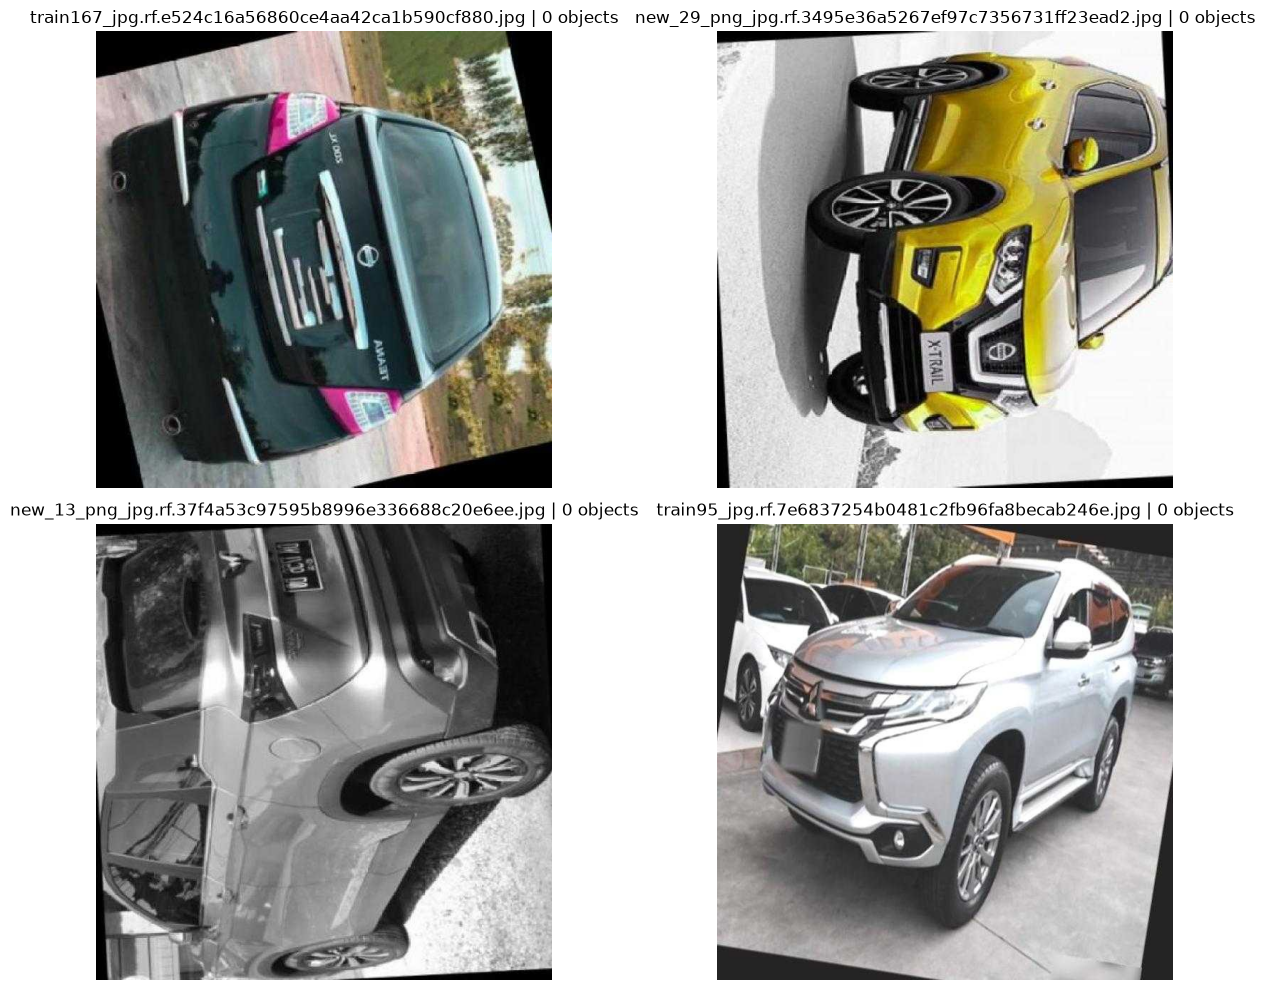

In [35]:
import random
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def load_yolo_annotations(label_path):
    annotations = []
    
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            
            if len(parts) != 5:
                continue
            
            class_id, x_center, y_center, width, height = map(float, parts)
            
            annotations.append({
                "class_id": int(class_id),
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })
    
    return annotations


# Select 4 random training images
train_image_dir = CARPARTS_DIR / "images" / "train"
train_images = [
    p for p in train_image_dir.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

sample_images = random.sample(train_images, min(4, len(train_images)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    
    label_path = CARPARTS_DIR / "labels" / "train" / f"{image_path.stem}.txt"
    annotations = load_yolo_annotations(label_path)
    
    img_width, img_height = image.size
    
    for ann in annotations:
        x_center = ann["x_center"] * img_width
        y_center = ann["y_center"] * img_height
        box_width = ann["width"] * img_width
        box_height = ann["height"] * img_height
        
        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2
        x2 = x_center + box_width / 2
        y2 = y_center + box_height / 2
        
        draw.rectangle([x1, y1, x2, y2], width=2)
        
        class_id = ann["class_id"]
        class_name = class_names[class_id]
        
        draw.text(
            (x1, max(0, y1 - 15)),
            class_name
        )
    
    ax.imshow(image)
    ax.set_title(f"{image_path.name} | {len(annotations)} objects")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Check Annotation Presence

Some images may have empty annotation files.
We check how many training images contain at least one annotated object.

This helps verify whether empty labels are expected in the dataset
or indicate a dataset preparation issue.

In [36]:
train_label_dir = CARPARTS_DIR / "labels" / "train"

total_train_images = 0
images_with_objects = 0
empty_label_files = 0

for image_path in train_images:
    total_train_images += 1
    
    label_path = train_label_dir / f"{image_path.stem}.txt"
    
    if not label_path.exists():
        continue
    
    with open(label_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
    
    if len(lines) > 0:
        images_with_objects += 1
    else:
        empty_label_files += 1

print(f"Total training images: {total_train_images}")
print(f"Images with annotations: {images_with_objects}")
print(f"Empty label files: {empty_label_files}")

Total training images: 3156
Images with annotations: 3040
Empty label files: 116


## Visualize Valid Annotated Samples

We select only images with non-empty annotation files and visualize
their bounding boxes.

This provides a reliable visual check of the YOLO annotations.

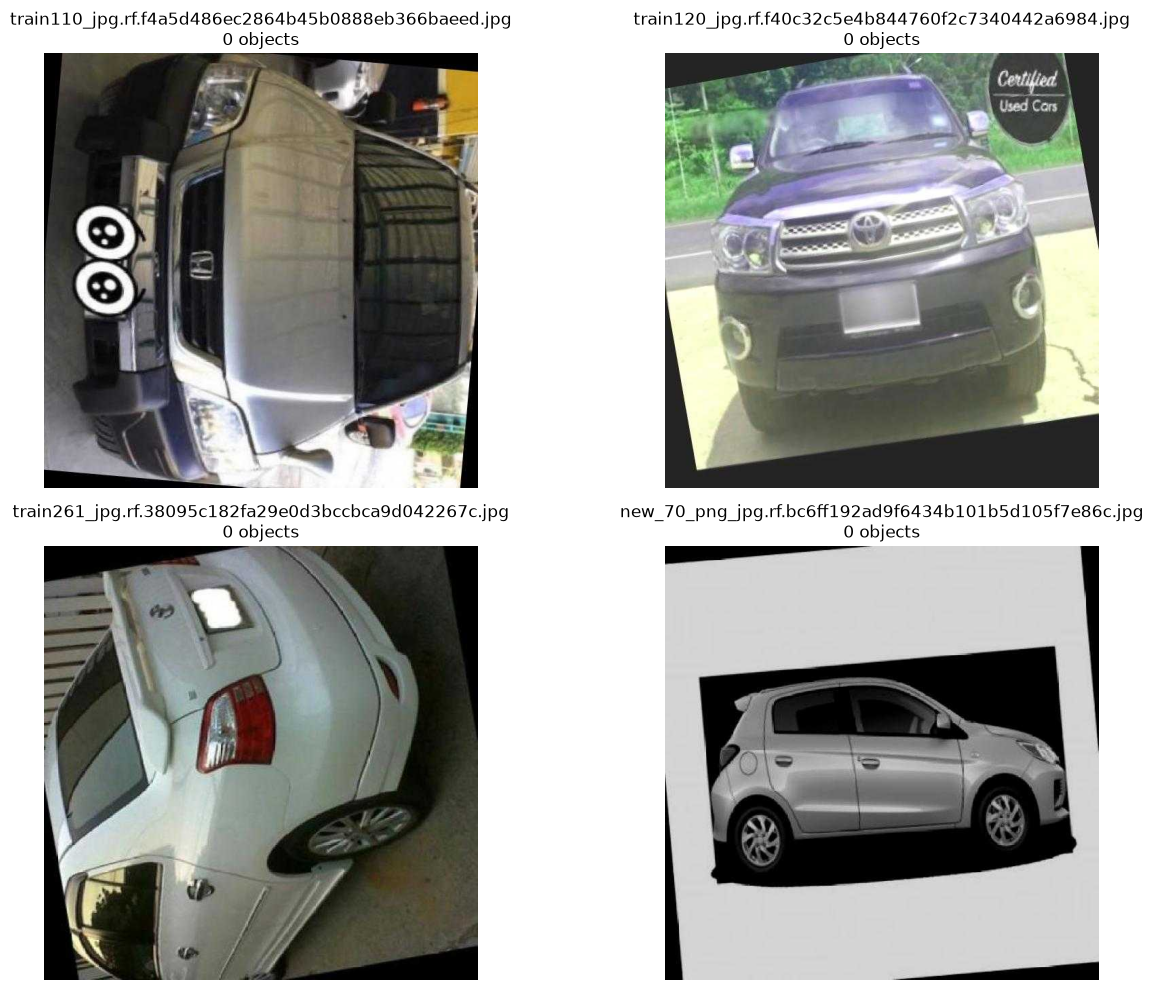

In [37]:
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Collect images that have at least one annotation
annotated_images = []

for image_path in train_images:
    label_path = train_label_dir / f"{image_path.stem}.txt"
    
    if not label_path.exists():
        continue
    
    with open(label_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
    
    if lines:
        annotated_images.append(image_path)

# Select 4 valid annotated images
sample_images = random.sample(
    annotated_images,
    min(4, len(annotated_images))
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    
    label_path = train_label_dir / f"{image_path.stem}.txt"
    annotations = load_yolo_annotations(label_path)
    
    img_width, img_height = image.size
    
    for ann in annotations:
        x_center = ann["x_center"] * img_width
        y_center = ann["y_center"] * img_height
        box_width = ann["width"] * img_width
        box_height = ann["height"] * img_height
        
        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2
        x2 = x_center + box_width / 2
        y2 = y_center + box_height / 2
        
        draw.rectangle(
            [x1, y1, x2, y2],
            width=2
        )
        
        class_name = class_names[ann["class_id"]]
        
        draw.text(
            (x1, max(0, y1 - 15)),
            class_name
        )
    
    ax.imshow(image)
    ax.set_title(
        f"{image_path.name}\n{len(annotations)} objects"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Inspect One YOLO Label File

We inspect one non-empty annotation file directly.

This verifies the annotation format before visualization.

In [38]:
# Select one image that has annotations
test_image = annotated_images[0]

test_label = train_label_dir / f"{test_image.stem}.txt"

print("Image:")
print(test_image)

print("\nLabel:")
print(test_label)

print("\nLabel file content:\n")

with open(test_label, "r", encoding="utf-8") as f:
    content = f.read()

print(content)

Image:
c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\images\train\car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.jpg

Label:
c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\labels\train\car10_jpg.rf.01c1346d0a306c6ba1a1b9c3fa7c9599.txt

Label file content:

2 0.46689453125 0.5880371656250001 0.5666015625 0.5780487812499999 0.63115234375 0.5738675953125 0.67255859375 0.5731707312500001 0.620703125 0.533565621875 0.5791015625 0.5063879203125 0.55830078125 0.503948896875 0.45654296875 0.503948896875 0.4076171875 0.5101045296875 0.43779296875 0.5558652734375 0.46689453125 0.5880371656250001
20 0.5333984375 0.647270615625 0.5396484375 0.6941927984375 0.54794921875 0.7239256671875001 0.5625 0.7535423921875 0.67880859375 0.7263646921875 0.73076171875 0.7114982578125 0.7390625 0.6818815328125 0.7390625 0.6423925671874999 0.7412109375 0.5979094078125 0.705859375 0.5830429734375 0.67255859375 0.5731707312500001 0.60615234375 0.57560975625 0.54375 0.5806039484375 0.

## Visualize YOLO Segmentation Annotations

The CarParts-Seg dataset uses YOLO segmentation annotations.
Each annotation contains a class ID followed by polygon coordinates.

We visualize the segmentation polygons directly on the images.

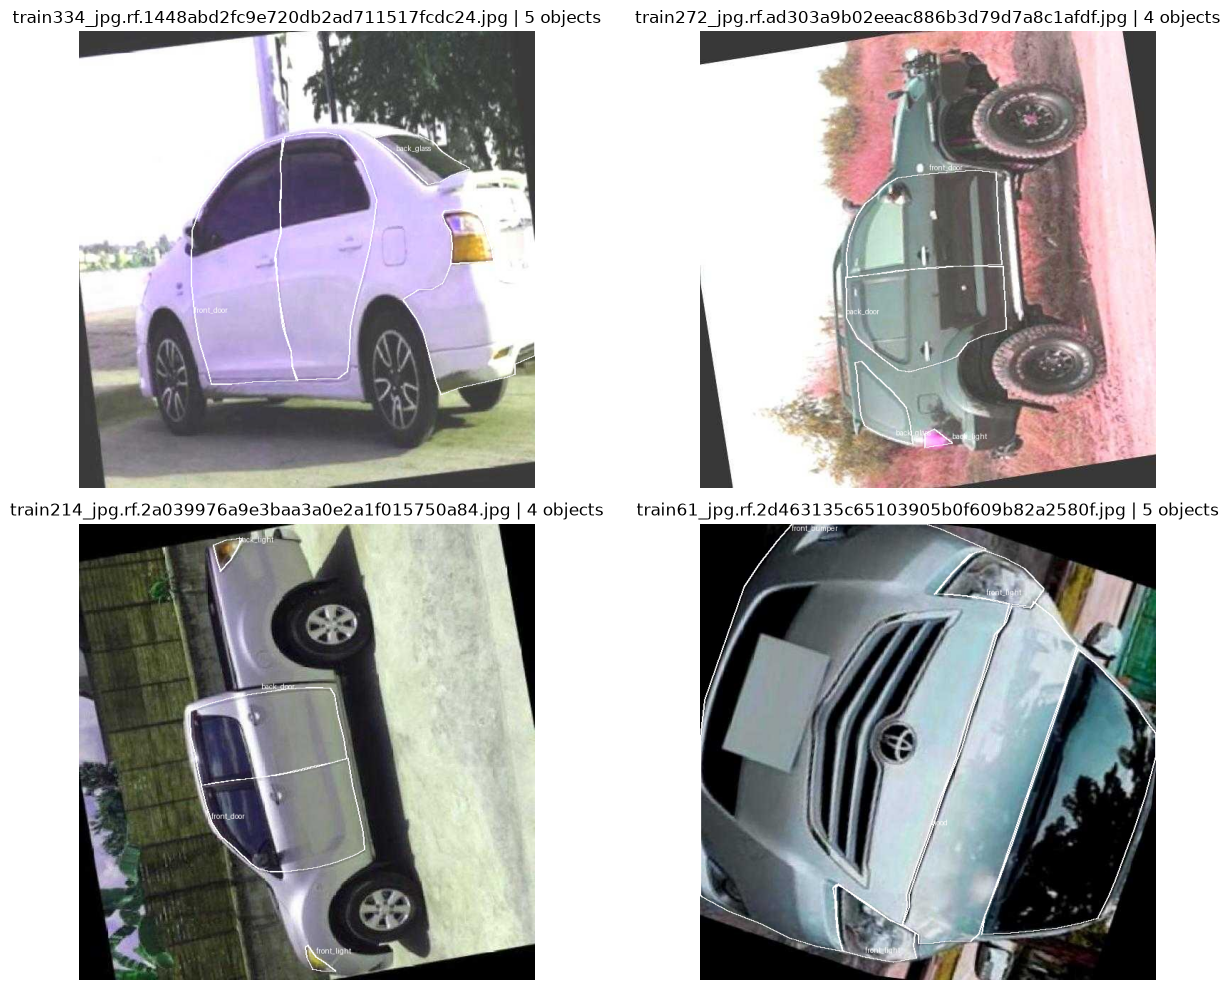

In [39]:
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


def load_yolo_segmentation(label_path):
    annotations = []

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 7:
                continue

            class_id = int(parts[0])
            coordinates = list(map(float, parts[1:]))

            # Coordinates must come in x,y pairs
            if len(coordinates) % 2 != 0:
                continue

            points = [
                (coordinates[i], coordinates[i + 1])
                for i in range(0, len(coordinates), 2)
            ]

            annotations.append({
                "class_id": class_id,
                "points": points
            })

    return annotations


# Select 4 images that contain annotations
sample_images = random.sample(
    annotated_images,
    min(4, len(annotated_images))
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    label_path = train_label_dir / f"{image_path.stem}.txt"
    annotations = load_yolo_segmentation(label_path)

    img_width, img_height = image.size

    for ann in annotations:
        pixel_points = [
            (
                int(x * img_width),
                int(y * img_height)
            )
            for x, y in ann["points"]
        ]

        # Draw segmentation polygon
        if len(pixel_points) >= 3:
            draw.line(
                pixel_points + [pixel_points[0]],
                width=2
            )

        class_name = class_names[ann["class_id"]]

        # Put label near the first polygon point
        if pixel_points:
            x, y = pixel_points[0]
            draw.text(
                (x, max(0, y - 15)),
                class_name
            )

    ax.imshow(image)
    ax.set_title(
        f"{image_path.name} | {len(annotations)} objects"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Save Dataset Inspection Summary

We save the main inspection results in a JSON file.

This summary documents the dataset size, classes, annotation counts,
and PDF statistics for reproducibility.

In [40]:
inspection_summary = {
    "pdf": {
        "file": PDF_PATH.name,
        "pages": num_pages,
        "pages_with_text": sum(bool(doc["text"]) for doc in cleaned_documents),
        "suspicious_pages": [item["page"] for item in suspicious_pages]
    },
    "carparts_seg": {
        "total_images": sum(
            len([
                p for p in (CARPARTS_DIR / "images" / split).iterdir()
                if p.is_file() and p.suffix.lower() in image_extensions
            ])
            for split in splits
        ),
        "splits": {
            split: {
                "images": len([
                    p for p in (CARPARTS_DIR / "images" / split).iterdir()
                    if p.is_file() and p.suffix.lower() in image_extensions
                ]),
                "labels": len([
                    p for p in (CARPARTS_DIR / "labels" / split).iterdir()
                    if p.is_file() and p.suffix.lower() == ".txt"
                ])
            }
            for split in splits
        },
        "num_classes": len(class_names),
        "class_names": class_names,
        "total_annotated_objects": sum(class_counts.values()),
        "empty_train_labels": empty_label_files,
        "image_label_mismatches": len(all_mismatches)
    }
}

SUMMARY_PATH = PROCESSED_DIR / "dataset_inspection_summary.json"

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        inspection_summary,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved: {SUMMARY_PATH}")
print(f"File exists: {SUMMARY_PATH.exists()}")

Saved: c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\data\processed\dataset_inspection_summary.json
File exists: True


## Notebook Summary

In this notebook, we inspected and prepared the main datasets for the CarCare AI project.

### What We Did

- Inspected the automotive maintenance PDF and extracted text from all 394 pages.
- Cleaned the extracted PDF text while preserving the original page numbers and source information.
- Identified a small number of suspicious PDF pages for later review without deleting them.
- Inspected the CarParts-Seg dataset and verified its train, validation, and test splits.
- Verified image-label matching across all dataset splits.
- Analyzed the 23 vehicle-part classes and their object distribution.
- Confirmed that the dataset uses YOLO segmentation annotations and visually verified the polygon boundaries.
- Saved the cleaned PDF data and dataset inspection summary as JSON files for use in the next stages.

### Output Files

- `data/processed/pdf_pages_cleaned.json`
- `data/processed/dataset_inspection_summary.json`

The cleaned PDF data will be used as the knowledge base for the RAG pipeline, while the CarParts-Seg dataset will be used later for vehicle-part detection and segmentation.